# Emergency Message Classification with DistilBERT

This notebook trains a DistilBERT model to classify emergency messages into different categories (medical, fire, flooding, trapped, etc.).

## 1. Import Required Libraries

In [15]:
# Import libraries for data processing, visualization, and model training
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch

## 2. Load Training Data

Load the synthetic emergency messages dataset from CSV file.

In [16]:
training_data_path = "sample.csv"
sample_data = pd.read_csv("./sample.csv")

sample_data.head()


,type,category,subcategory,priority,message
0,medical,medical,heavy_bleeding,1.0,Someone is hurt!. person bleeding heavily. Pat...
1,disaster,flooding,flash_flood,1.0,hlp pls. flash flood coming. sudden flood wate...
2,disaster,flooding,flash_flood,1.0,hlp pls. sudden flood waters rising. Waiting f...
3,disaster,infrastructure_damage,road,5.0,emergency situation. road collapse. send someo...
4,disaster,supply_request,clothing,4.0,help!!. need cloths. need clothes. Requesting ...


## 3. Explore the Data

Examine the structure and contents of the dataset.

In [17]:
sample_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   type         10000 non-null  str    
 1   category     10000 non-null  str    
 2   subcategory  9480 non-null   str    
 3   priority     9357 non-null   float64
 4   message      10000 non-null  str    
dtypes: float64(1), str(4)
memory usage: 1.4 MB


In [18]:
sample_data.nunique()

type              2
category         11
subcategory      32
priority          5
message        9779
dtype: int64

In [19]:
cat_cols = [
    "type",
    "category",
    "subcategory",
    "message"
]

## 4. Data Preprocessing

Clean the data and visualize the distribution of priorities and categories.

In [20]:
sample_data[cat_cols].T

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
type,medical,disaster,disaster,disaster,disaster,medical,medical,medical,medical,disaster,...,medical,disaster,disaster,disaster,medical,disaster,medical,medical,disaster,medical
category,medical,flooding,flooding,infrastructure_damage,supply_request,medical,medical,medical,medical,fire,...,medical,trapped,supply_request,structure_damage,medical,structure_damage,medical,medical,utility,medical
subcategory,heavy_bleeding,flash_flood,flash_flood,road,clothing,injury,unconscious,heavy_bleeding,illness,wildfire,...,injury,in_building,other,severe,light_bleeding,light,injury,unconscious,gas_leak,illness
message,Someone is hurt!. person bleeding heavily. Pat...,hlp pls. flash flood coming. sudden flood wate...,hlp pls. sudden flood waters rising. Waiting f...,emergency situation. road collapse. send someo...,help!!. need cloths. need clothes. Requesting ...,urgent hlp needed. work accident hurt. breathi...,Medical emergency!. hit head and unconscious. ...,need ambulance rn. deep cut bleeding heavily. ...,urgent hlp needed. suddenly became ill. urgent...,Need urgent assistance!. fire out of control. ...,...,Someone is hurt!. arm broke or smth. unconscio...,help us. cant get out. help needed now.,emergency situation. need assistance with reso...,Anyone there?. trapped under debris. pls respond.,Help help. small wound bleeding. condition get...,help us. roof partially damaged. cracks in wal...,omg need help. head injry bad. situation bad. ...,Medical emergency!. completely unresponsive. P...,anybody there. strong gas odor. gas leak detec...,Medical emergency!. she sick bad. really urgen...


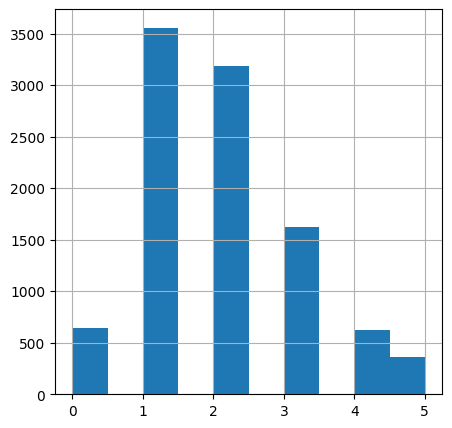

category
medical                  5000
structure_damage          526
other                     520
utility                   511
missing_person            508
supply_request            506
flooding                  497
trapped                   491
fire                      489
infrastructure_damage     483
evacuation                469
Name: count, dtype: int64


In [21]:
# apply priority 0 to events without priority
sample_data = sample_data.fillna({"priority": 0})

sample_data["priority"].hist(figsize=(5,5))
plt.show()

# print out all categories and their counts
print(sample_data["category"].value_counts())

## 5. Map Categories to Numeric Labels

Convert category names to numeric labels for model training.

In [22]:
categories = {
    "other": 0,
    "medical": 1,
    "structure_damage": 2,
    "utility": 3,
    "missing_person": 4,
    "supply_request": 5,
    "flooding": 6,
    "trapped": 7,
    "fire": 8,
    "infrastructure_damage": 9,
    "evacuation": 10,
}

sample_data_mapped_categories = sample_data
sample_data_mapped_categories["category"] = sample_data_mapped_categories["category"].map(categories)
sample_data_mapped_categories.head()


,type,category,subcategory,priority,message
0,medical,1,heavy_bleeding,1.0,Someone is hurt!. person bleeding heavily. Pat...
1,disaster,6,flash_flood,1.0,hlp pls. flash flood coming. sudden flood wate...
2,disaster,6,flash_flood,1.0,hlp pls. sudden flood waters rising. Waiting f...
3,disaster,9,road,5.0,emergency situation. road collapse. send someo...
4,disaster,5,clothing,4.0,help!!. need cloths. need clothes. Requesting ...


## 6. Prepare Training Data

Split data into training (70%), validation (15%), and test (15%) sets.

In [31]:
# Prepare data for training
X = sample_data_mapped_categories["message"]
y = sample_data_mapped_categories["category"]

# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 7000
Validation samples: 1500
Test samples: 1500


## 7. Tokenize and Create Datasets

Initialize the DistilBERT tokenizer and create HuggingFace datasets with tokenized messages.

In [12]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
def tokenize(batch):
    return tokenizer(batch["message"].tolist(), padding=True, truncation=True)

# Create datasets
def create_dataset(texts, labels):
    """Create a Hugging Face Dataset from texts and labels"""
    encodings = tokenizer(texts.tolist(), truncation=True, padding=True)
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels.tolist()
    })
    return dataset

train_dataset = create_dataset(X_train, y_train)
val_dataset = create_dataset(X_val, y_val)
test_dataset = create_dataset(X_test, y_test)

print("Datasets created successfully!")
print(f"Train dataset: {train_dataset}")
print(f"Val dataset: {val_dataset}")
print(f"Test dataset: {test_dataset}")

Datasets created successfully!
Train dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7000
})
Val dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1500
})
Test dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1500
})


## 8. Initialize the Model

Load the pre-trained DistilBERT model and configure it for sequence classification.

In [13]:
# Initialize the DistilBERT model for sequence classification
num_labels = len(categories)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

print(f"Model initialized with {num_labels} labels")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1105.30it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cpu
Model initialized with 11 labels


## 9. Define Evaluation Metrics

Set up metrics (accuracy, F1, precision, recall) to evaluate model performance.

In [14]:
# Define metrics computation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

## 10. Configure Training Parameters

Set up training arguments and initialize the Trainer.

In [15]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer initialized and ready for training!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer initialized and ready for training!


## 11. Train the Model

Train the DistilBERT model on the emergency message dataset. This will take several minutes.

In [16]:
# Train the model
print("Starting training...")
train_result = trainer.train()
print("Training completed!")
print(f"\nTraining metrics:")
for key, value in train_result.metrics.items():
    print(f"  {key}: {value}")

Starting training...


/home/zack/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.036813,0.011677,0.997333,0.997334,0.997369,0.997333
2,0.013834,0.008631,0.998000,0.998001,0.998079,0.998000
3,0.004121,0.005513,0.998000,0.998001,0.998079,0.998000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.65it/s]
/home/zack/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.83it/s]
/home/zack/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.83it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed!

Training metrics:
  train_runtime: 685.8193
  train_samples_per_second: 30.62
  train_steps_per_second: 1.916
  total_flos: 201061892178000.0
  train_loss: 0.2587751946447465
  epoch: 3.0


## 12. Evaluate Model Performance

Test the trained model on validation and test sets to measure accuracy and other metrics.

In [18]:
# Evaluate on validation set
print("Evaluating on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)
print(f"\nValidation metrics:")
for key, value in val_results.items():
    print(f"  {key}: {value:.4f}")

print("Evaluating on test set...")
test_results = trainer.evaluate(eval_dataset=test_dataset)
print(f"\nTest metrics:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

Evaluating on validation set...


/home/zack/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Validation metrics:
  eval_loss: 0.0086
  eval_accuracy: 0.9980
  eval_f1: 0.9980
  eval_precision: 0.9981
  eval_recall: 0.9980
  eval_runtime: 8.5053
  eval_samples_per_second: 176.3600
  eval_steps_per_second: 2.8220
  epoch: 3.0000
Evaluating on test set...


/home/zack/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test metrics:
  eval_loss: 0.0060
  eval_accuracy: 0.9987
  eval_f1: 0.9987
  eval_precision: 0.9987
  eval_recall: 0.9987
  eval_runtime: 7.1787
  eval_samples_per_second: 208.9510
  eval_steps_per_second: 3.3430
  epoch: 3.0000


## 13. Save Model

In [19]:
# Save the final model
model.save_pretrained('./emergency_distilbert_model')
tokenizer.save_pretrained('./emergency_distilbert_model')
print("\nModel saved to './emergency_distilbert_model'")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]


Model saved to './emergency_distilbert_model'


## 14. Test Predictions

Test the model with sample emergency messages to see how it classifies different types of emergencies.

In [ ]:
# Test prediction on sample messages
def predict_message(text):
    """Predict category for a new emergency message"""
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item()
        confidence = predictions[0][predicted_class].item()
    
    # Get category name
    category_names = {v: k for k, v in categories.items()}
    category_name = category_names[predicted_class]
    
    return category_name, confidence

# Test with sample messages
test_messages = [
    "fire",
    "ambulance",
    "fire in building",
    "going to die",
    "gas smell",
    "going to explode",
    "my butt is on fire"
]

print("Testing predictions on sample messages:\n")
for msg in test_messages:
    category, confidence = predict_message(msg)
    print(f"Message: {msg}")
    print(f"Predicted category: {category} (confidence: {confidence:.2%})\n")

Testing predictions on sample messages:

Message: fire
Predicted category: fire (confidence: 99.81%)

Message: ambulance
Predicted category: other (confidence: 31.29%)

Message: fire in building
Predicted category: fire (confidence: 99.81%)

Message: going to die
Predicted category: trapped (confidence: 91.42%)

Message: gas smell
Predicted category: utility (confidence: 99.82%)

Message: going to explode
Predicted category: fire (confidence: 79.35%)

Message: my butt is on fire
Predicted category: fire (confidence: 99.82%)



## Load Existing Model

If you want to use a previously trained model without retraining, you can load it from disk:

In [1]:
# Load a previously trained model
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import torch

# Path to the saved model
model_path = './models/emergency_distilbert_model'

# Load the model and tokenizer
loaded_model = DistilBertForSequenceClassification.from_pretrained(model_path)
loaded_tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

# Move model to appropriate device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)
loaded_model.eval()

print(f"Model loaded successfully from '{model_path}'")
print(f"Model is on device: {device}")
print(f"Model has {loaded_model.config.num_labels} output labels")

/home/zack/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 239.71it/s, Materializing param=pre_classifier.weight]                                 


Model loaded successfully from './models/emergency_distilbert_model'
Model is on device: cpu
Model has 11 output labels


In [12]:
categories = {
    "other": 0,
    "medical": 1,
    "structure_damage": 2,
    "utility": 3,
    "missing_person": 4,
    "supply_request": 5,
    "flooding": 6,
    "trapped": 7,
    "fire": 8,
    "infrastructure_damage": 9,
    "evacuation": 10,
}

# Use the loaded model for predictions
def predict_with_loaded_model(text, model, tokenizer, device):
    """Predict category using a loaded model"""
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item()
        confidence = predictions[0][predicted_class].item()
    
    # Get category name
    category_names = {v: k for k, v in categories.items()}
    category_name = category_names[predicted_class]
    
    return category_name, confidence

# Test the loaded model
test_message = "fire here hlp"
category, confidence = predict_with_loaded_model(test_message, loaded_model, loaded_tokenizer, device)
print(f"Test message: {test_message}")
print(f"Predicted category: {category}")
print(f"Confidence: {confidence:.2%}")

Test message: fire here hlp
Predicted category: fire
Confidence: 99.82%
